# Analysis of the Reconstructed Matrices

In [125]:
from pathlib import Path
import json
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


# Step 1: Load Full Reconstructed Dataset (Local PC)
Load reconstructed matrices.

In [126]:
WINDOW_LENGTH = 724
STRIDE = 10
DATASET_NAME = f'data_00_20_w{WINDOW_LENGTH}_s{STRIDE}'
RUN_NAME = 'linearAE_005'
FILE_NAME = f'all_reconstructed_{RUN_NAME}.pt'

project_root = Path.cwd().resolve().parent
base_dir = project_root / 'data' / 'processed' / 'dataset'
dataset_dir = base_dir / DATASET_NAME

ALL_RECONSTRUCTED_MATRIX_FILE = dataset_dir / FILE_NAME
RESULTS_FOLDER = project_root / 'results' / DATASET_NAME / 'reconstruction_analysis' / RUN_NAME
RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)

if not ALL_RECONSTRUCTED_MATRIX_FILE.exists():
    raise FileNotFoundError(
        f"File '{ALL_RECONSTRUCTED_MATRIX_FILE.name}' not found in: {dataset_dir.absolute()}"
    )

print(f'Dataset selected: {DATASET_NAME}')
print(f'All Reconstructed Matrix: {ALL_RECONSTRUCTED_MATRIX_FILE.name}')

Dataset selected: data_00_20_w724_s10
All Reconstructed Matrix: all_reconstructed_linearAE_005.pt


In [127]:
def load_corr_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')
    corr_tensor = payload.get('corr_tensor', None)
    recon_tensor = payload.get('corr_tensor_reconstructed', None)
    indices = payload.get('indices', None)
    meta = {k: v for k, v in payload.items() if k != 'corr_tensor'}

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')
    if recon_tensor is None:
        raise KeyError('corr_tensor_reconstructed key not found in .pt file')
    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')
    if recon_tensor.ndim != 3 or recon_tensor.shape[1] != recon_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor_reconstructed: {recon_tensor.shape}')

    return corr_tensor.float(), recon_tensor.float(), indices, meta


gt_corr, recon_corr, indices, meta = load_corr_payload(ALL_RECONSTRUCTED_MATRIX_FILE)

print(f'Ground truth correlation tensor shape: {gt_corr.shape}')
print(f'Reconstructed correlation tensor shape: {recon_corr.shape}')
print(f'Indices: {indices[:10]}')
print(f'Metadata keys: {list(meta.keys())}')
print(gt_corr[:1,:5,:5])
print(recon_corr[:1,:5,:5])

num_windows, num_assets, _ = gt_corr.shape
print(f'\nNumber of windows: {num_windows}, Number of assets: {num_assets}')


Ground truth correlation tensor shape: torch.Size([412, 362, 362])
Reconstructed correlation tensor shape: torch.Size([412, 362, 362])
Indices: [49, 50, 51, 52, 53, 54, 55, 56, 57, 58]
Metadata keys: ['indices', 'split', 'meta', 'corr_tensor_reconstructed']
tensor([[[1.0000, 0.1305, 0.1530, 0.2544, 0.4250],
         [0.1305, 1.0000, 0.1224, 0.3038, 0.1635],
         [0.1530, 0.1224, 1.0000, 0.1499, 0.2088],
         [0.2544, 0.3038, 0.1499, 1.0000, 0.2217],
         [0.4250, 0.1635, 0.2088, 0.2217, 1.0000]]])
tensor([[[0.8124, 0.2094, 0.2340, 0.2101, 0.3013],
         [0.2125, 0.7667, 0.1785, 0.2375, 0.1749],
         [0.1788, 0.1856, 0.8463, 0.2609, 0.2713],
         [0.2061, 0.2639, 0.1971, 0.8735, 0.3032],
         [0.3189, 0.2817, 0.2321, 0.2207, 0.8040]]])

Number of windows: 412, Number of assets: 362


In [128]:
SAMPLE_IDX = 49
SAMPLE_FOLDER = RESULTS_FOLDER / f'sample_{SAMPLE_IDX}'


if SAMPLE_IDX not in indices:
    raise ValueError(f'SAMPLE_IDX {SAMPLE_IDX} not found in indices list')

orig_mat = gt_corr[SAMPLE_IDX].detach().cpu().numpy()
recon_mat = recon_corr[SAMPLE_IDX].detach().cpu().numpy()
err_mat = recon_mat - orig_mat

print(f'Sample index: {SAMPLE_IDX}\n')
print(f"Original Matrix:\n{orig_mat[:5, :5]}")  # Print the top-left 5x5 block of the original matrix for inspection
print(f"Reconstructed Matrix:\n{recon_mat[:5, :5]}")  # Print the top-left 5x5 block of the reconstructed matrix for inspection
print(f"Error Matrix:\n{err_mat[:5, :5]}")  # Print the top-left 5x5 block of the error matrix for inspection

mse_sample = float(np.mean((err_mat) ** 2))
mae_sample = float(np.mean(np.abs(err_mat)))
fro_sample = float(np.linalg.norm(err_mat, ord='fro'))


print(f'\nMSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')
print(f'Original Matrix range - Min: {orig_mat.min():.6f} | Max: {orig_mat.max():.6f}')
print(f'Reconstructed Matrix range - Min: {recon_mat.min():.6f} | Max: {recon_mat.max():.6f}')
print(f'Error range - Min: {err_mat.min():.6f} | Max: {err_mat.max():.6f}')


Sample index: 49

Original Matrix:
[[1.     0.0807 0.1503 0.1593 0.2778]
 [0.0807 1.     0.1496 0.2186 0.1323]
 [0.1503 0.1496 1.     0.204  0.1445]
 [0.1593 0.2186 0.204  1.     0.1421]
 [0.2778 0.1323 0.1445 0.1421 1.    ]]
Reconstructed Matrix:
[[0.7284 0.1962 0.2321 0.1897 0.2519]
 [0.1995 0.6499 0.1674 0.1875 0.1158]
 [0.1491 0.1785 0.7805 0.2637 0.266 ]
 [0.1863 0.2274 0.1731 0.8208 0.3006]
 [0.2823 0.2688 0.2097 0.1816 0.7125]]
Error Matrix:
[[-0.2716  0.1154  0.0818  0.0304 -0.0259]
 [ 0.1187 -0.3501  0.0177 -0.0311 -0.0166]
 [-0.0013  0.0289 -0.2195  0.0597  0.1215]
 [ 0.0269  0.0088 -0.0309 -0.1792  0.1585]
 [ 0.0045  0.1365  0.0651  0.0395 -0.2875]]

MSE: 0.008692 | MAE: 0.072945 | Frobenius: 33.750393
Original Matrix range - Min: -0.105261 | Max: 1.000000
Reconstructed Matrix range - Min: -0.085849 | Max: 0.922497
Error range - Min: -0.463778 | Max: 0.497683


# Property 0: Heatmap Analysis

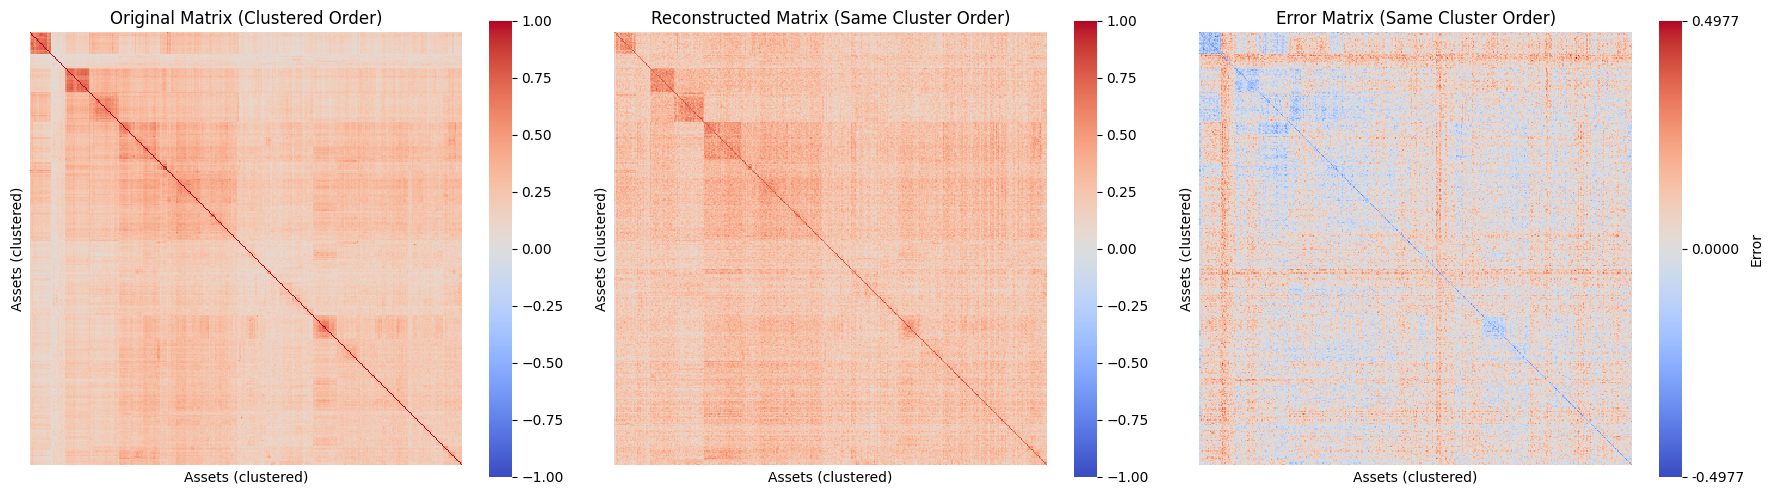

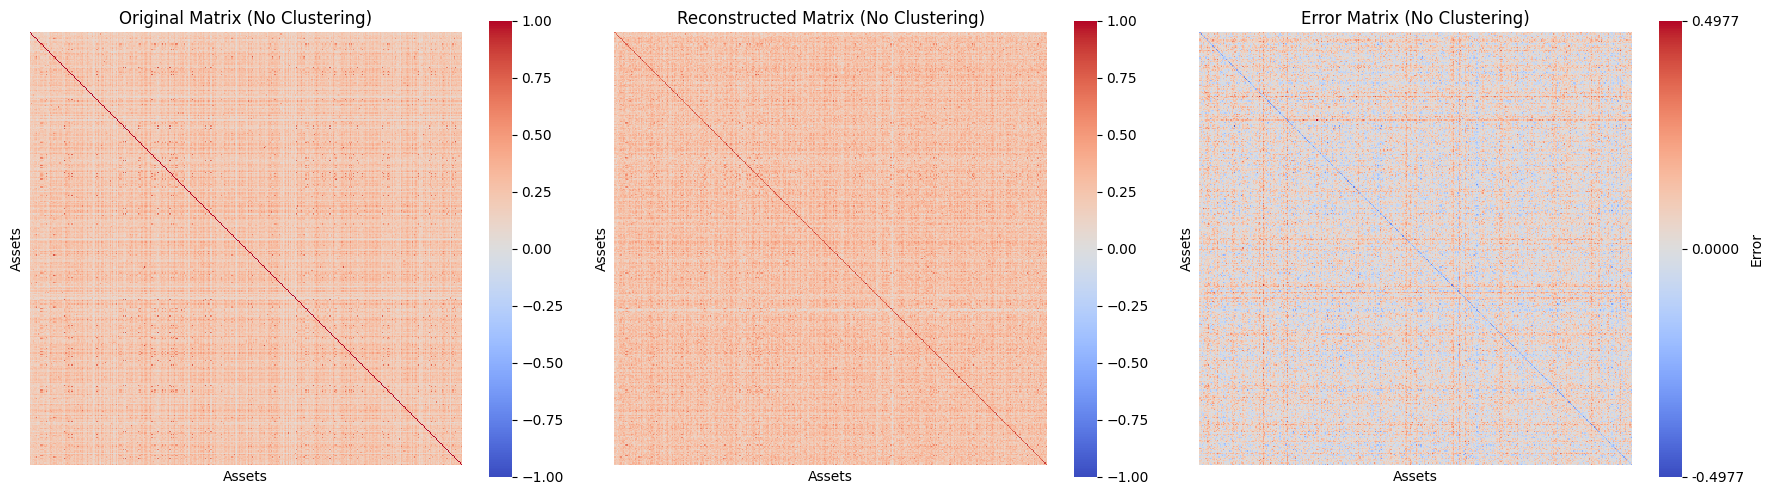

Saved heatmaps for matrix index 49:
 - C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\results\data_00_20_w724_s10\reconstruction_analysis\linearAE_005\sample_49\property0\clustered_heatmaps.png
 - C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\results\data_00_20_w724_s10\reconstruction_analysis\linearAE_005\sample_49\property0\no_clustered_heatmaps.png


In [129]:
PROPERTY_0_FOLDER = SAMPLE_FOLDER / 'property0'
PROPERTY_0_FOLDER.mkdir(parents=True, exist_ok=True)

shared_cmap = 'coolwarm'
err_abs_max = float(np.max(np.abs(err_mat)))
if err_abs_max == 0:
    err_abs_max = 1e-6

# Build a single cluster ordering from the original matrix and reuse it for all three panels.
cluster_ref = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
row_order = cluster_ref.dendrogram_row.reordered_ind
col_order = cluster_ref.dendrogram_col.reordered_ind
plt.close(cluster_ref.figure)

orig_mat_clustered = orig_mat[np.ix_(row_order, col_order)]
recon_mat_clustered = recon_mat[np.ix_(row_order, col_order)]
err_mat_clustered = err_mat[np.ix_(row_order, col_order)]

fig_cluster, axes_cluster = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    orig_mat_clustered,
    ax=axes_cluster[0],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[0].set_title('Original Matrix (Clustered Order)')

sns.heatmap(
    recon_mat_clustered,
    ax=axes_cluster[1],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[1].set_title('Reconstructed Matrix (Same Cluster Order)')

hm_cluster_err = sns.heatmap(
    err_mat_clustered,
    ax=axes_cluster[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_cluster[2].set_title('Error Matrix (Same Cluster Order)')

cbar_cluster = hm_cluster_err.collections[0].colorbar
cbar_cluster.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_cluster.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes_cluster:
    ax.set_xlabel('Assets (clustered)')
    ax.set_ylabel('Assets (clustered)')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_cluster = PROPERTY_0_FOLDER / 'clustered_heatmaps.png'
fig_cluster.savefig(path_cluster, dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[0].set_title('Original Matrix (No Clustering)')

sns.heatmap(recon_mat, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[1].set_title('Reconstructed Matrix (No Clustering)')

hm = sns.heatmap(
    err_mat,
    ax=axes[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes[2].set_title('Error Matrix (No Clustering)')

cbar_std = hm.collections[0].colorbar
cbar_std.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_std.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_no_cluster = PROPERTY_0_FOLDER / 'no_clustered_heatmaps.png'
fig.savefig(path_no_cluster, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved heatmaps for matrix index {SAMPLE_IDX}:')
print(f' - {path_cluster}')
print(f' - {path_no_cluster}')

# Property 1: The distribution of pairwise correlations is significantly shifted towards positive values


✓ Comparison plot saved to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\results\data_00_20_w724_s10\reconstruction_analysis\linearAE_005\sample_49\property1\correlation_comparison_distribution.png

--- Statistics for Ground Truth ---
Mean: 0.2340 | Std: 0.0910 | Min: -0.1053 | Max: 0.8364
Positive: 65311 (99.95%) | Negative: 30 (0.05%) | Zero: 0 (0.00%)

--- Statistics for Reconstruction ---
Mean: 0.2662 | Std: 0.0919 | Min: -0.0849 | Max: 0.7721
Positive: 65307 (99.95%) | Negative: 34 (0.05%) | Zero: 0 (0.00%)


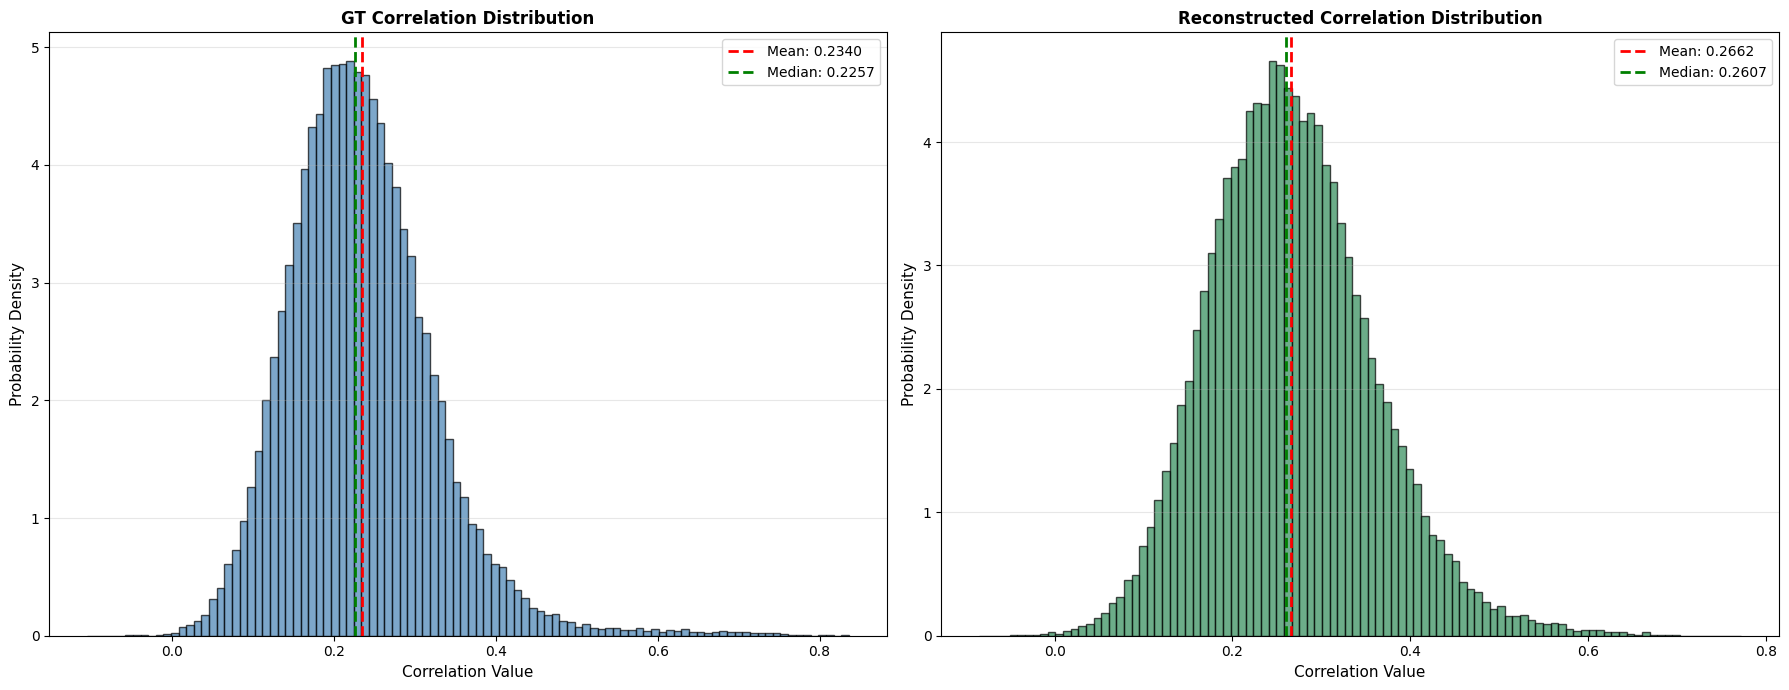

In [130]:
PROPERTY_1_FOLDER = SAMPLE_FOLDER / 'property1'
PROPERTY_1_FOLDER.mkdir(parents=True, exist_ok=True)


triu_indices = torch.triu_indices(num_assets, num_assets, offset=1)

# Estrazione valori per Ground Truth e Reconstruction
gt_values = gt_corr[SAMPLE_IDX][triu_indices[0], triu_indices[1]]
recon_values = recon_corr[SAMPLE_IDX][triu_indices[0], triu_indices[1]]

# --- Visualizzazione ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Grafico 1: Ground Truth Correlation
ax1.hist(gt_values.numpy(), bins=100, color='steelblue', edgecolor='black', alpha=0.7, density=True)
ax1.axvline(torch.mean(gt_values).item(), color='red', linestyle='--', linewidth=2, label=f'Mean: {torch.mean(gt_values):.4f}')
ax1.axvline(torch.median(gt_values).item(), color='green', linestyle='--', linewidth=2, label=f'Median: {torch.median(gt_values):.4f}')
ax1.set_xlabel('Correlation Value', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.set_title(f'GT Correlation Distribution', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Grafico 2: Reconstructed Correlation
ax2.hist(recon_values.numpy(), bins=100, color='seagreen', edgecolor='black', alpha=0.7, density=True)
ax2.axvline(torch.mean(recon_values).item(), color='red', linestyle='--', linewidth=2, label=f'Mean: {torch.mean(recon_values):.4f}')
ax2.axvline(torch.median(recon_values).item(), color='green', linestyle='--', linewidth=2, label=f'Median: {torch.median(recon_values):.4f}')
ax2.set_xlabel('Correlation Value', fontsize=11)
ax2.set_ylabel('Probability Density', fontsize=11)
ax2.set_title(f'Reconstructed Correlation Distribution', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Salvataggio
plot_path = PROPERTY_1_FOLDER / 'correlation_comparison_distribution.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Comparison plot saved to: {plot_path}")

# --- Statistiche veloci in console ---
def print_stats(name, values):
    print(f"\n--- Statistics for {name} ---")
    print(f"Mean: {torch.mean(values):.4f} | Std: {torch.std(values):.4f} | Min: {torch.min(values):.4f} | Max: {torch.max(values):.4f}")
    pos = torch.sum(values > 0).item()
    neg = torch.sum(values < 0).item()
    zero = torch.sum(values == 0).item()
    print(f"Positive: {pos} ({100*pos/len(values):.2f}%) | Negative: {neg} ({100*neg/len(values):.2f}%) | Zero: {zero} ({100*zero/len(values):.2f}%)")

print_stats("Ground Truth", gt_values)
print_stats("Reconstruction", recon_values)

plt.show()

# Property 2: Eigenvalues follow the Marchenko–Pastur distribution, except for a very large first eigenvalue and a couple of other large eigenvalues

In [134]:
PROPERTY_2_FOLDER = SAMPLE_FOLDER / 'property2'
PROPERTY_2_FOLDER.mkdir(parents=True, exist_ok=True)

print(f"Computing eigendecomposition for sample index {SAMPLE_IDX}...")

evals_gt, evecs_gt = torch.linalg.eigh(gt_corr[SAMPLE_IDX])
evals_recon, evecs_recon = torch.linalg.eigh(recon_corr[SAMPLE_IDX])

# Reverse to get descending order (highest eigenvalues first)
evals_gt = torch.flip(evals_gt, dims=[0])
evecs_gt = torch.flip(evecs_gt, dims=[1])
evals_recon = torch.flip(evals_recon, dims=[0])
evecs_recon = torch.flip(evecs_recon, dims=[1])

print(f"✓ Eigendecomposition complete!")

evals_gt_np = evals_gt.cpu().numpy()
evals_recon_np = evals_recon.cpu().numpy()
evecs_gt_np = evecs_gt.cpu().numpy()
evecs_recon_np = evecs_recon.cpu().numpy()
negative_eigenvalues_count_gt = np.sum(evals_gt_np < 0)
negative_eigenvalues_count_recon = np.sum(evals_recon_np < 0)
print(f"\nNumber of negative eigenvalues (Ground Truth): {negative_eigenvalues_count_gt}")
print(f"Number of negative eigenvalues (Reconstruction): {negative_eigenvalues_count_recon}")

Computing eigendecomposition for sample index 49...
✓ Eigendecomposition complete!

Number of negative eigenvalues (Ground Truth): 0
Number of negative eigenvalues (Reconstruction): 140


In [132]:
# ===== MARCHENKO-PASTUR FUNCTION =====
def marchenko_pastur_pdf(x, lmbd, sigma=1):
    """
    Marchenko-Pastur probability density function.

    Parameters:
    -----------
    x : float or array
        Eigenvalue
    lmbd : float
        Ratio of num_eigenvalues / num_time_points (N/T)
    sigma : float
        Standard deviation (typically 1 for correlation matrices)

    Returns:
    --------
    float or array
        Probability density at x
    """
    b = np.power(sigma * (1 + np.sqrt(lmbd)), 2)  # Largest eigenvalue
    a = np.power(sigma * (1 - np.sqrt(lmbd)), 2)  # Smallest eigenvalue

    # Vectorized calculation
    result = np.zeros_like(x, dtype=float)
    mask = (x >= a) & (x <= b)
    result[mask] = (1 / (2 * np.pi * sigma * sigma * x[mask] * lmbd)) * np.sqrt((b - x[mask]) * (x[mask] - a))

    return result

✓ Comparison plot saved to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\results\data_00_20_w724_s10\reconstruction_analysis\linearAE_005\sample_49\property2\eigenvalue_comparison_marchenko_pastur.png

--- Eigenvalue Statistics ---
Eigenvalues above MP limit (GT): 9 | Max GT Eigenvalue: 88.906654
Eigenvalues above MP limit (Recon): 9 | Max Recon Eigenvalue: 98.994255
Eigenvalues below MP limit (GT): 29 | Min GT Eigenvalue: 0.039010
Eigenvalues below MP limit (Recon): 148 | Min Recon Eigenvalue: -1.940411

Negative eigenvalues (GT): 0
Negative eigenvalues (Recon): 140


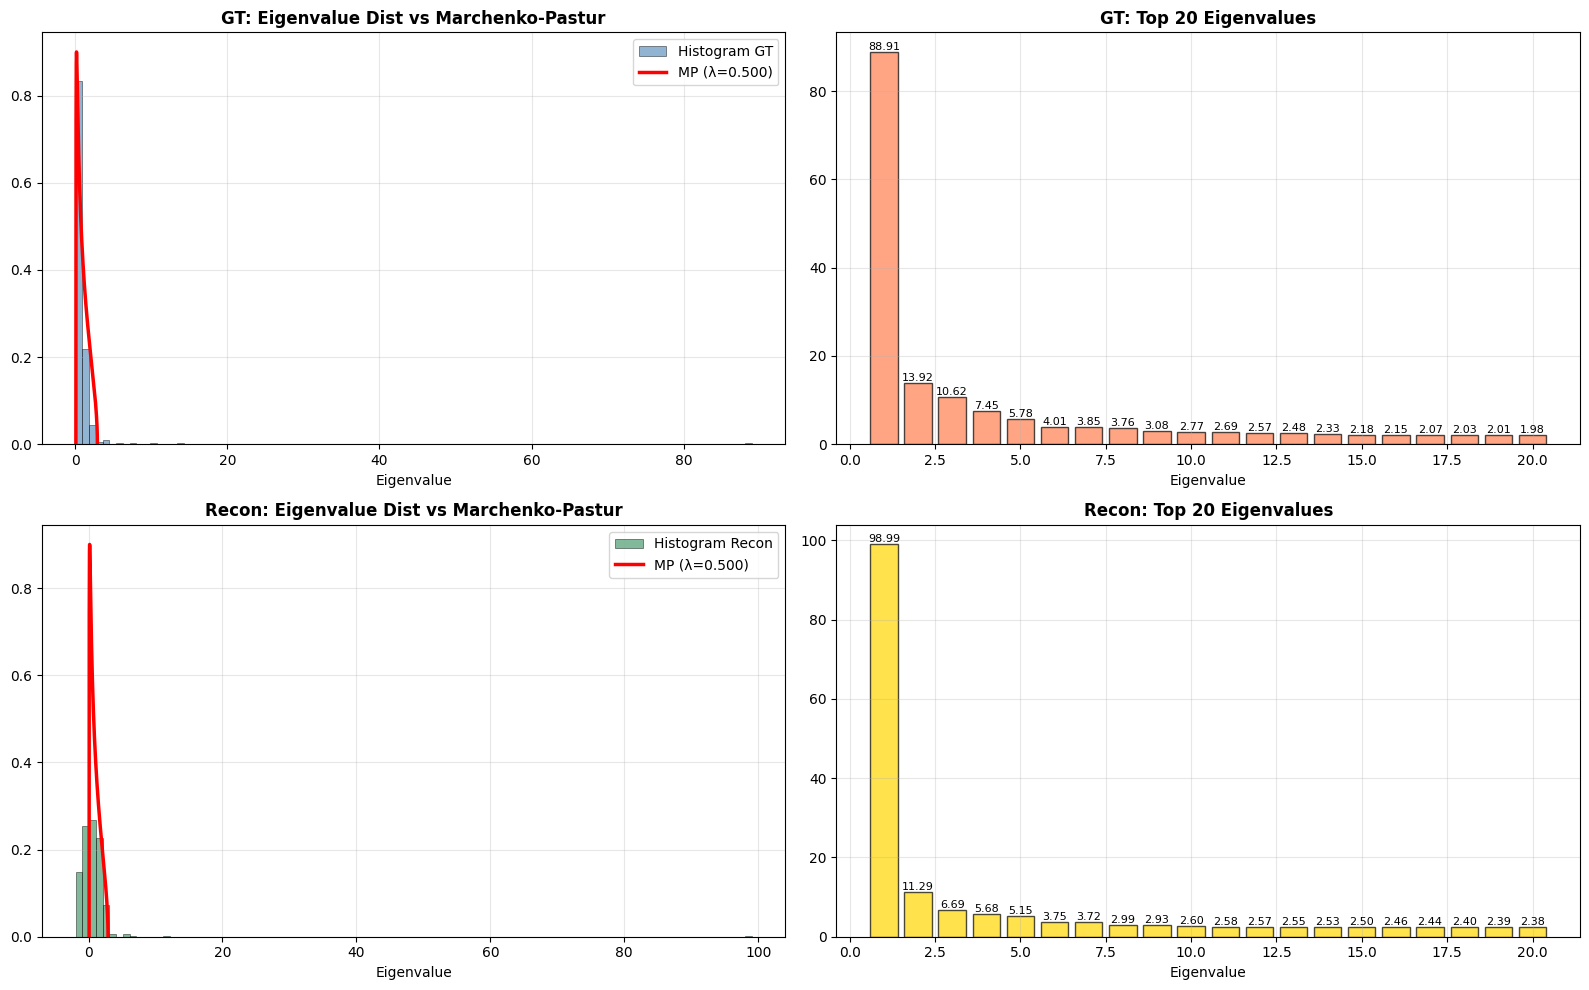

In [133]:
# Calcolo parametri MP (comuni a entrambi)
lmbd = num_assets / WINDOW_LENGTH
sigma = 1.0
b = np.power(sigma * (1 + np.sqrt(lmbd)), 2)
a = np.power(sigma * (1 - np.sqrt(lmbd)), 2)
x_theory = np.linspace(a, b, 500)
y_theory = marchenko_pastur_pdf(x_theory, lmbd, sigma)

# Creazione figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- RIGA 1: GROUND TRUTH (evals_gt_np) ---
data_gt = evals_gt_np
top_k = min(20, len(data_gt))

# Plot 1,1: Istogramma GT
axes[0, 0].hist(data_gt, bins=100, density=True, alpha=0.6, color='steelblue', edgecolor='black', linewidth=0.5, label='Histogram GT')
axes[0, 0].plot(x_theory, y_theory, 'r-', linewidth=2.5, label=f'MP (λ={lmbd:.3f})')
axes[0, 0].set_title('GT: Eigenvalue Dist vs Marchenko-Pastur', fontweight='bold')
axes[0, 0].legend()

# Plot 1,2: Top Eigenvalues GT
top_gt = np.sort(data_gt)[::-1][:top_k]
axes[0, 1].bar(np.arange(1, top_k + 1), top_gt, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title(f'GT: Top {top_k} Eigenvalues', fontweight='bold')
for i, val in enumerate(top_gt):
    axes[0, 1].text(i+1, val, f'{val:.2f}', ha='center', va='bottom', fontsize=8)

# --- RIGA 2: RECONSTRUCTED (evals_recon_np) ---
data_recon = evals_recon_np

# Plot 2,1: Istogramma Recon
axes[1, 0].hist(data_recon, bins=100, density=True, alpha=0.6, color='seagreen', edgecolor='black', linewidth=0.5, label='Histogram Recon')
axes[1, 0].plot(x_theory, y_theory, 'r-', linewidth=2.5, label=f'MP (λ={lmbd:.3f})')
axes[1, 0].set_title('Recon: Eigenvalue Dist vs Marchenko-Pastur', fontweight='bold')
axes[1, 0].legend()

# Plot 2,2: Top Eigenvalues Recon
top_recon = np.sort(data_recon)[::-1][:top_k]
axes[1, 1].bar(np.arange(1, top_k + 1), top_recon, color='gold', edgecolor='black', alpha=0.7)
axes[1, 1].set_title(f'Recon: Top {top_k} Eigenvalues', fontweight='bold')
for i, val in enumerate(top_recon):
    axes[1, 1].text(i+1, val, f'{val:.2f}', ha='center', va='bottom', fontsize=8)

# Formattazione comune
for ax in axes.flat:
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Eigenvalue')

plt.tight_layout()

# Salvataggio e Print statistiche (facoltativo per i Recon)
plot_path = PROPERTY_2_FOLDER / 'eigenvalue_comparison_marchenko_pastur.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Comparison plot saved to: {plot_path}")

print(f"\n--- Eigenvalue Statistics ---")
print(f"Eigenvalues above MP limit (GT): {np.sum(data_gt > b)} | Max GT Eigenvalue: {np.max(data_gt):.6f}")
print(f"Eigenvalues above MP limit (Recon): {np.sum(data_recon > b)} | Max Recon Eigenvalue: {np.max(data_recon):.6f}")
print(f"Eigenvalues below MP limit (GT): {np.sum(data_gt < a)} | Min GT Eigenvalue: {np.min(data_gt):.6f}")
print(f"Eigenvalues below MP limit (Recon): {np.sum(data_recon < a)} | Min Recon Eigenvalue: {np.min(data_recon):.6f}")
print()
print(f"Negative eigenvalues (GT): {np.sum(data_gt < 0)}")
print(f"Negative eigenvalues (Recon): {np.sum(data_recon < 0)}")

plt.show()

# Property 3: The Perron-Frobenius property holds true (first eigenvector has positive entries and has multiplicity one)


OVERLAY COMPARISON: TOP 3 EIGENVECTORS (sample index 49)
Eigenvector #1 (Market Mode):
  GT    -> PF Satisfied: True, Min: 0.016176
  Recon -> PF Satisfied: True, Min: 0.020919

✓ Overlay comparison plot saved to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\results\data_00_20_w724_s10\reconstruction_analysis\linearAE_005\sample_49\property3\perron_frobenius.png


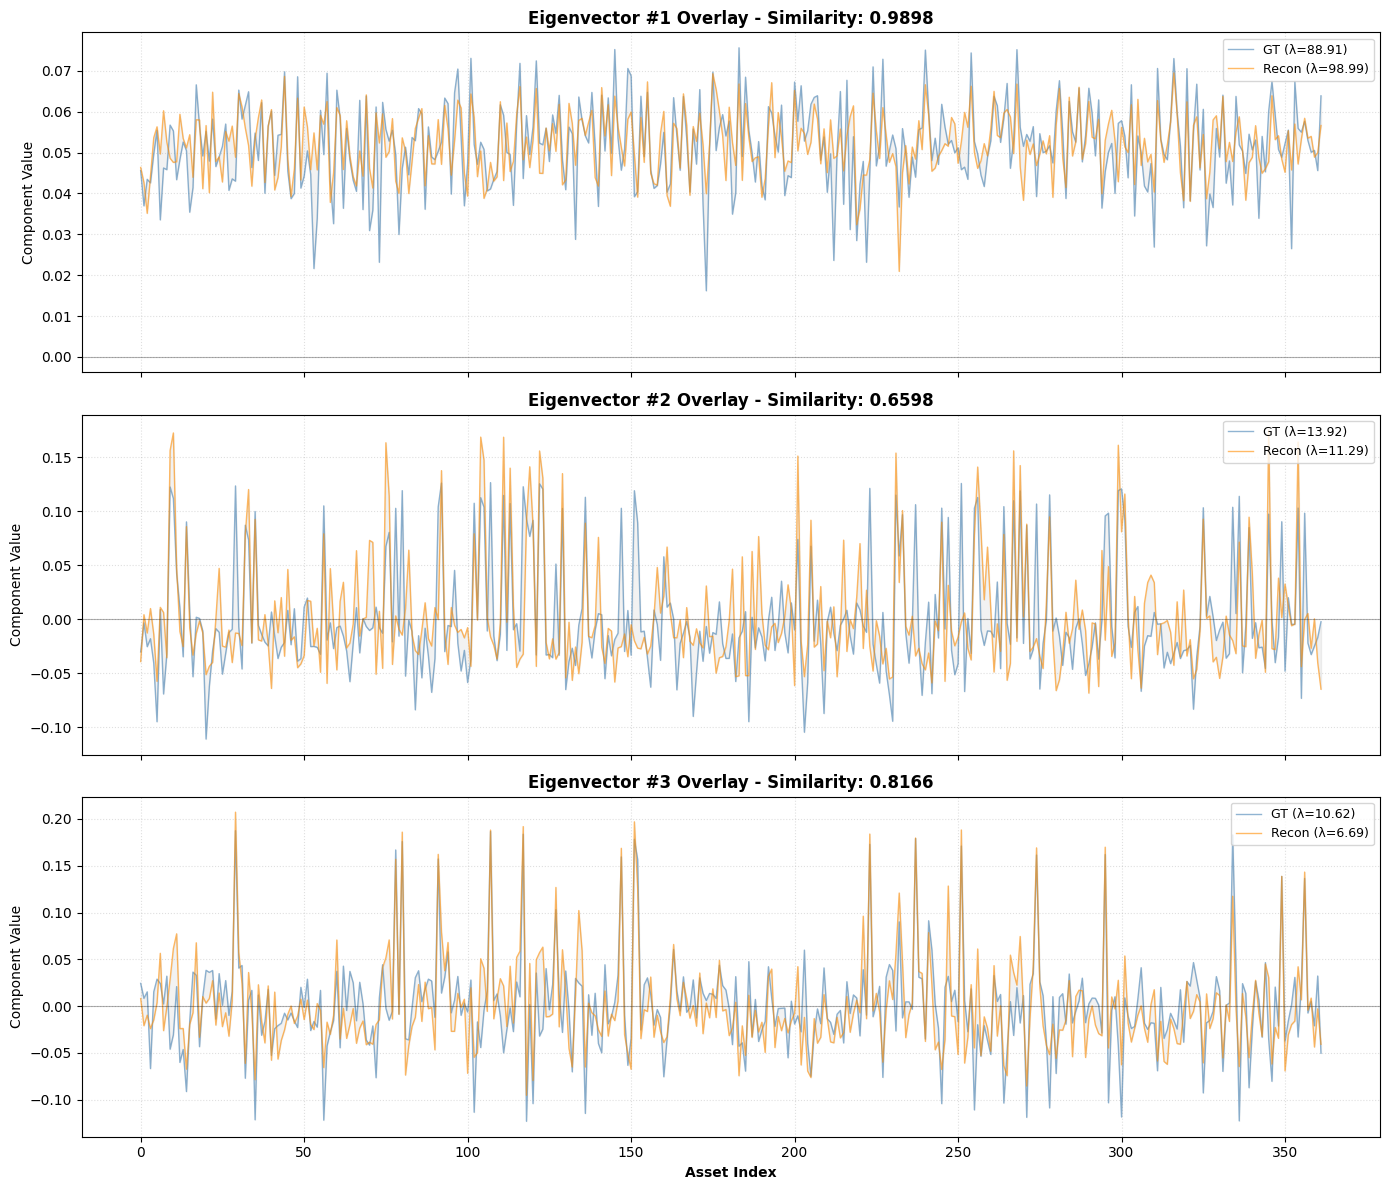

In [141]:
PROPERTY_3_FOLDER = SAMPLE_FOLDER / 'property3'
PROPERTY_3_FOLDER.mkdir(parents=True, exist_ok=True)

def process_eigenvector(vec):
    """Normalizza il segno dell'autovettore per coerenza nel confronto."""
    v = vec.copy()
    if np.sum(v) < 0:
        v = -v
    return v

print(f"\n{'='*60}")
print(f"OVERLAY COMPARISON: TOP 3 EIGENVECTORS (sample index {SAMPLE_IDX})")
print(f"{'='*60}")

# Figura con 3 righe, linee sottili e sovrapposte
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
asset_idx = np.arange(num_assets)

for eig_idx in range(3):
    # --- Estrazione e Processamento ---
    vec_gt = process_eigenvector(evecs_gt_np[:, eig_idx])
    vec_recon = process_eigenvector(evecs_recon_np[:, eig_idx])
    val_gt = evals_gt_np[eig_idx]
    val_recon = evals_recon_np[eig_idx]
    
    ax = axes[eig_idx]
    
    # --- Plot Lineare con Trasparenza e Linee Sottili ---
    # GT Line: Blu acciaio, sottile, semi-trasparente
    ax.plot(asset_idx, vec_gt, label=f'GT (λ={val_gt:.2f})', 
            color='steelblue', lw=1, alpha=0.6)
    
    # Recon Line: Arancio scuro, sottile, semi-trasparente
    ax.plot(asset_idx, vec_recon, label=f'Recon (λ={val_recon:.2f})', 
            color='darkorange', lw=1, alpha=0.6)
    
    # Riempimento dell'area di intersezione per migliorare la visibilità
    ax.fill_between(asset_idx, vec_gt, vec_recon, color='gray', alpha=0.1)
    
    # --- Metriche e Titoli ---
    similarity = np.dot(vec_gt, vec_recon) / (np.linalg.norm(vec_gt) * np.linalg.norm(vec_recon))
    
    ax.set_title(f"Eigenvector #{eig_idx+1} Overlay - Similarity: {similarity:.4f}", 
                 fontweight='bold', fontsize=12)
    ax.axhline(0, color='black', lw=0.8, alpha=0.3)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
    ax.set_ylabel('Component Value')

    # Logica Perron-Frobenius
    if eig_idx == 0:
        pf_gt = np.all(vec_gt >= -1e-5)
        pf_recon = np.all(vec_recon >= -1e-5)
        print(f"Eigenvector #1 (Market Mode):")
        print(f"  GT    -> PF Satisfied: {pf_gt}, Min: {np.min(vec_gt):.6f}")
        print(f"  Recon -> PF Satisfied: {pf_recon}, Min: {np.min(vec_recon):.6f}")

axes[-1].set_xlabel('Asset Index', fontweight='bold')

plt.tight_layout()

# Salvataggio
plot_path = PROPERTY_3_FOLDER / 'perron_frobenius.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Overlay comparison plot saved to: {plot_path}")

plt.show()